In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [46]:
class Expert(nn.Module):
    """A standard feedforward network that serves as an Expert."""
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.ffl1 = nn.Linear(in_dim, hidden_dim)
        self.ffl2 = nn.Linear(hidden_dim, in_dim)
    
    def forward(self, x):
        out1 = self.ffl1(x)
        out2 = self.ffl2(F.silu(out1))

        return out2

In [47]:
from utils import visualize_matrix

class MoELayer(nn.Module):
    """The Mixture of Experts Layer."""
    def __init__(self, in_dim, hidden_dim, num_experts, top_k=2):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k

        self.router = nn.Linear(in_dim, num_experts, bias=False)

        self.experts = nn.ModuleList(
            [ Expert(in_dim, hidden_dim) for _ in range(self.num_experts)]
        )
    
    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        print(
            f'Batch Size: {batch_size} \n',
            f'Sequence Length: {seq_len} \n',
            f'Embedding Dimension: {d_model} \n',
        )

        x_flat = x.view(-1, d_model)
        print(
            f'Flattened Dimension: {x_flat.shape} \n',
        )

        router_logits = self.router(x_flat)
        routing_probs = F.softmax(router_logits, dim=-1)
        print(
            f'Router Output shape: {routing_probs.shape} \n',
        )
        visualize_matrix(routing_probs, x_label='Router Probabilities for Experts', y_label='Tokens')

        top_k_probs, top_k_indices = torch.topk(routing_probs, self.top_k, dim=-1)
        top_k_probs = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)

        visualize_matrix(
            top_k_probs, 
            x_label=f'Router Probabilities for top {self.top_k} Experts', 
            y_label='Tokens'
        )
        visualize_matrix(
            top_k_indices, 
            x_label=f'Expert Indices for top {self.top_k} Experts', 
            y_label='Tokens'
        )

        final_output = torch.zeros_like(x_flat)

        for i, expert in enumerate(self.experts):
            print(f'Current Expert index: {i}')
            expert_mask = (top_k_indices == i)
            visualize_matrix(
                expert_mask, 
                x_label=f'Expert Mask', 
                y_label='Tokens'
            )

            token_indices = expert_mask.any(dim=-1)
            print(token_indices)

            if not token_indices.any():
                print('Skipping the Expert, since it has no tokens to attend')
                continue
                
            token_for_expert = x_flat[token_indices]
            visualize_matrix(
                token_for_expert, 
                x_label=f'Embedding Dimension', 
                y_label='Selected Tokens for Expert to attend',
                width=15,
            )

            expert_output = expert(token_for_expert)
            visualize_matrix(
                expert_output, 
                x_label=f'Embedding Dimension', 
                y_label='Expert Output for Selected Tokens',
                width=15,
            )

            weight_indices = expert_mask[token_indices].nonzero(as_tuple=True)[1]
            print(
                'Weight Indices \n',
                f'0 -- Current Expert is the 1st choice of the Token \n',
                f'1 -- Current Expert is the 2nd choice of the Token',
            )
            print(weight_indices)

            token_weights = top_k_probs[token_indices, weight_indices].unsqueeze(-1)
            visualize_matrix(
                token_weights, 
                x_label=f'Weights for the current Expert', 
                y_label='Tokens',
                width=3,
            )

            final_expert_output = expert_output * token_weights
            visualize_matrix(
                final_expert_output, 
                x_label=f'Final Expert Output', 
                y_label='Tokens',
                width=15,
            )

            final_output[token_indices] += final_expert_output
            visualize_matrix(
                final_output, 
                x_label=f'Final Output Weights', 
                y_label='Tokens',
                width=15,
            )
            break

        return final_output.view(batch_size, seq_len, d_model)

Batch Size: 2 
 Sequence Length: 4 
 Embedding Dimension: 16 

Flattened Dimension: torch.Size([8, 16]) 

Router Output shape: torch.Size([8, 8]) 



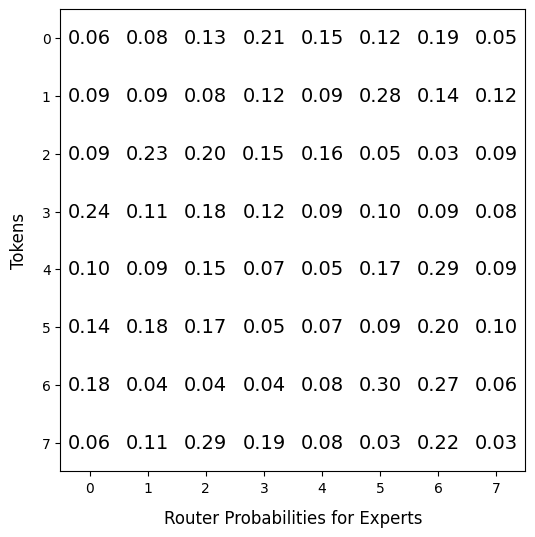

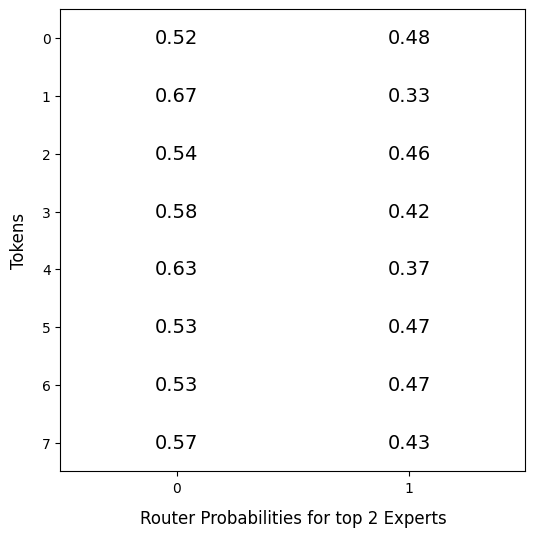

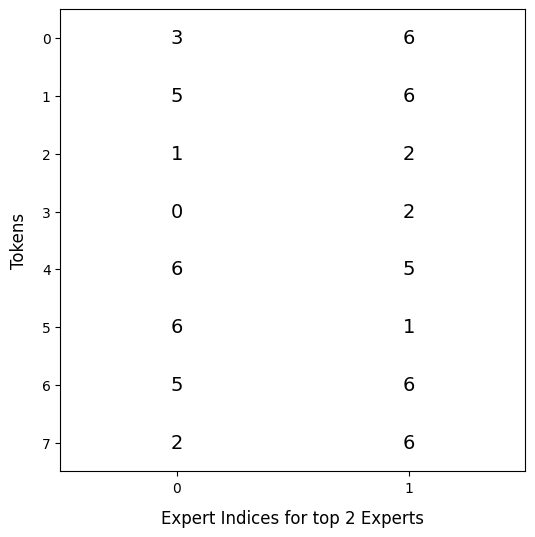

Current Expert index: 0


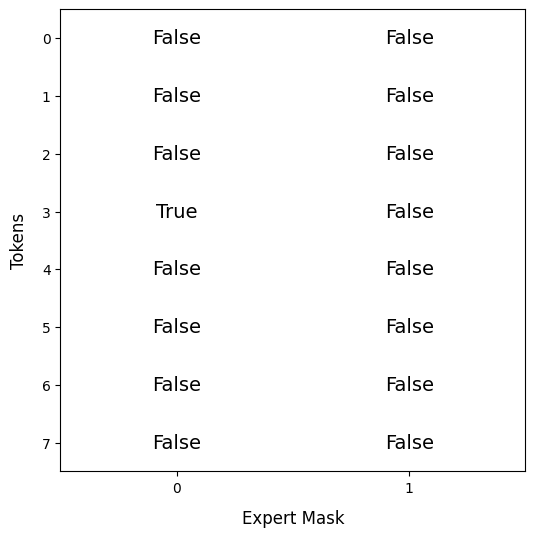

tensor([False, False, False,  True, False, False, False, False])


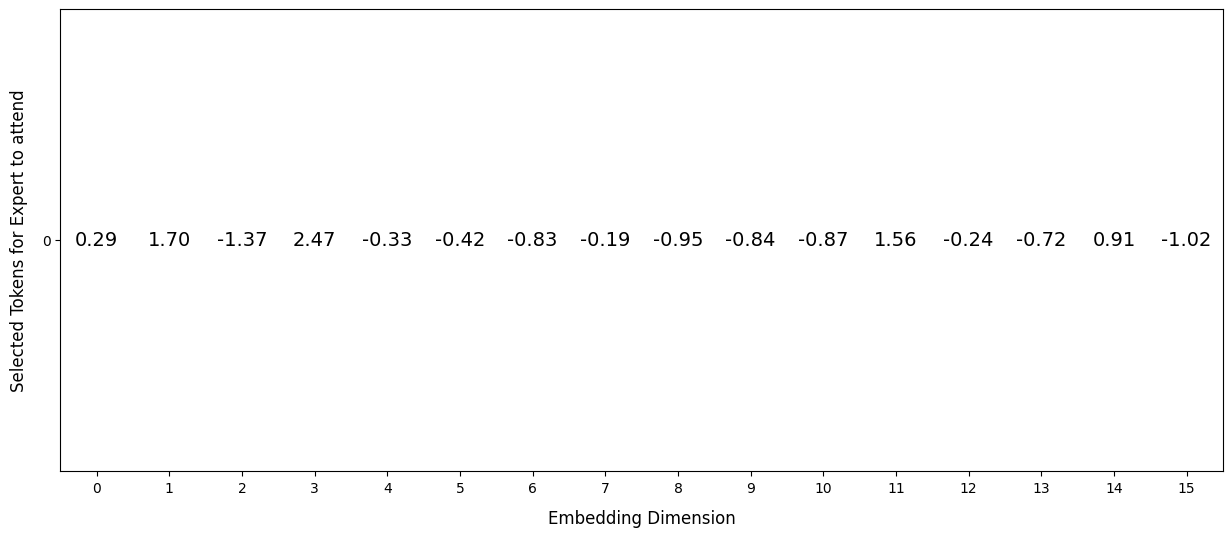

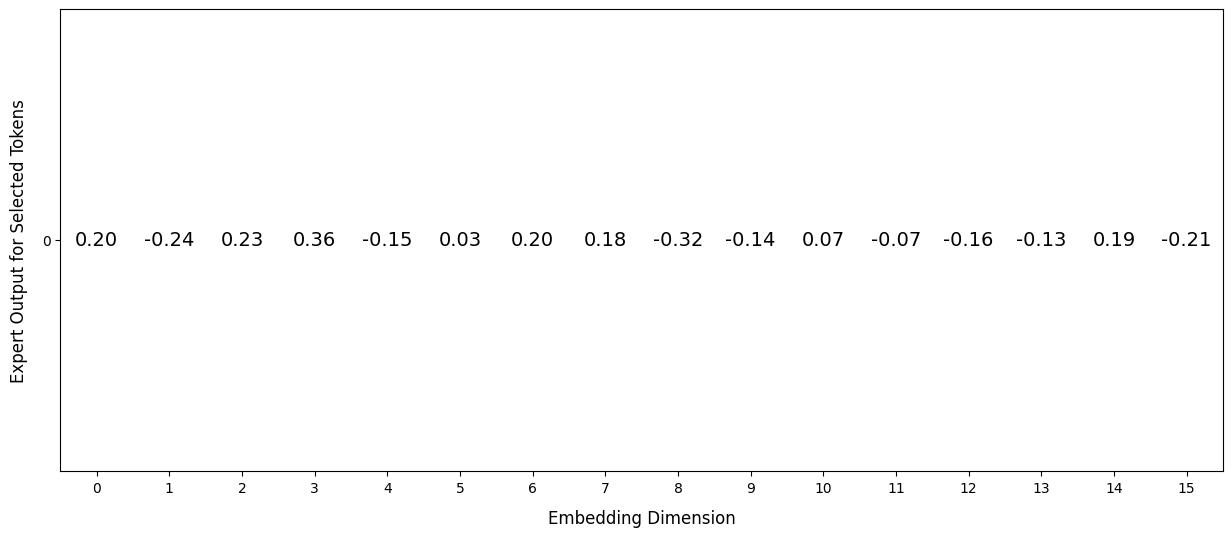

Weight Indices 
 0 -- Current Expert is the 1st choice of the Token 
 1 -- Current Expert is the 2nd choice of the Token
tensor([0])


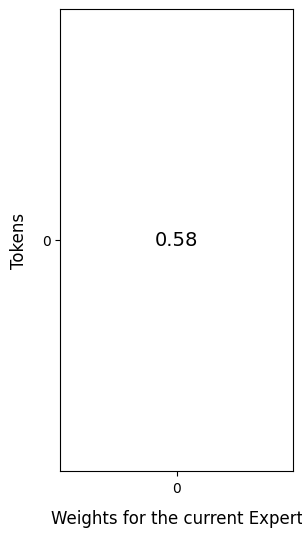

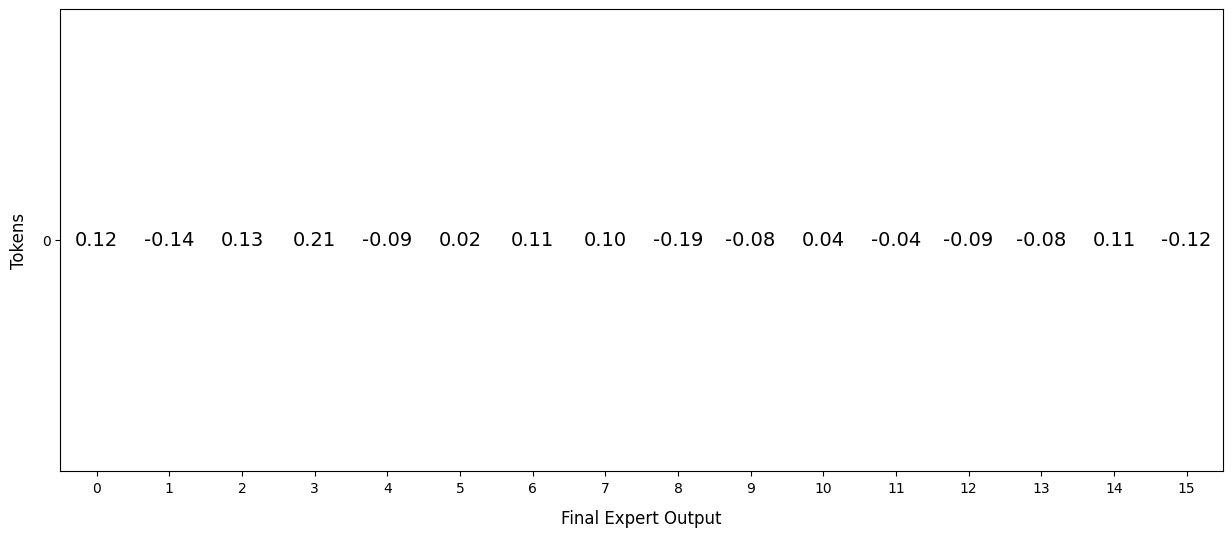

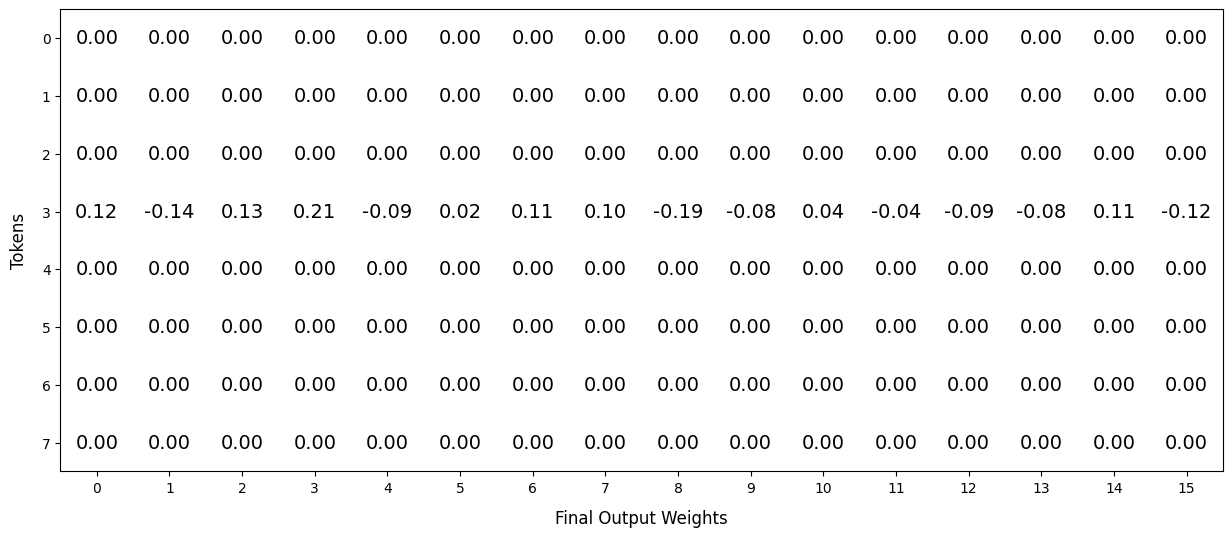

In [48]:
def runner():
    d_model, hidden_dim = 16, 32
    num_experts, top_k = 8, 2

    # Create random dummy text data (Batch: 2, Sequence Length: 4)
    x = torch.randn(2, 4, d_model)

    # Initialize our MoE layer
    moe_layer = MoELayer(d_model, hidden_dim, num_experts, top_k)

    # Run the forward pass
    output = moe_layer(x)
    # print(f"Input shape: {x.shape}")
    # print(f"Output shape: {output.shape}")

runner()